# Bivariate Poisson goal prediction

Current experiment based on the [historical workflow](legacy/prediction.ipynb). Historical code and outputs are preserved in `legacy/`, with portable setup/model paths. Implementation is in `../src/prediction_bivariate.py`; results below are embedded from its completed run. Notebook cells have not themselves been executed by a Jupyter kernel.

The same RF grid and train/test files are used. A five-coefficient joint likelihood layer learns match-specific unshared home, unshared away, and shared rates from out-of-fold training predictions. Both exact probabilities and 50,000 joint simulations per match are evaluated. A calibrated independent control helps isolate the dependence contribution.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/prediction_bivariate.py").is_file())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
import pandas as pd
import prediction_bivariate as experiment

# Set True to rerun training and simulation (several minutes).
RERUN = False
if RERUN or not (experiment.OUT / "model_metrics.csv").exists():
    experiment.main()


## One random forest predicting a goal vector
The new `RF_vector` model trains one native multi-output forest with **2,000 trees** on `Y_train = [home_score, away_score]`. Both targets influence the same tree splits. Training uses `forest.fit(X_train, Y_train)` and predictions have shape `(n_matches, 2)`. It uses `criterion="squared_error"` and out-of-bag MSE evaluation, holding prior settings fixed. Predictions average leaf means. These point predictions use the original independent Poisson conversion as a heuristic for betting evaluation; shared trees alone do not define a dependent score distribution. The cell below loads the already-trained forest; set `REFIT_VECTOR=True` to refit just this model.

In [ ]:
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
SEED, OUT = experiment.SEED, experiment.OUT

def fit_vector_forest(xtrain, xtest, ytrain):
    """One native multi-output forest, with both goals influencing each split."""
    forest = RandomForestRegressor(n_estimators=2000, criterion='squared_error',
                                   max_depth=5, max_features=0.3, max_samples=0.5,
                                   oob_score=mean_squared_error,
                                   random_state=SEED, n_jobs=4, verbose=1)
    # Hold the previous train-CV-selected settings fixed to isolate the loss change.
    # OOB MSE evaluates training rows using only trees that did not sample them.
    forest.fit(xtrain, ytrain)  # ytrain has TWO columns: [home_goals, away_goals].
    vectors = forest.predict(xtest)  # (n_matches, 2), with shared tree structure.
    assert forest.n_outputs_ == 2 and len(forest.estimators_) == 2000
    assert all(tree.n_outputs_ == 2 for tree in forest.estimators_)
    assert vectors.shape == (len(xtest), 2) and np.isfinite(vectors).all()
    assert (vectors >= 0).all()
    joblib.dump(forest, OUT / 'vector_forest.joblib')
    params = {'max_features': 0.3, 'max_samples': 0.5,
              'oob_mse': float(forest.oob_score_), 'selection': 'fixed_previous_CV_settings'}
    old_cv = OUT / 'vector_cv_results.csv'
    if old_cv.exists():
        old_cv.rename(OUT / 'vector_previous_poisson_cv_results.csv')
    pd.DataFrame([params]).to_csv(OUT / 'vector_fit_details.csv', index=False)
    return vectors, params


In [ ]:
import joblib
X_train, X_test, Y_train, Y_test, *_ = experiment.prepare()
REFIT_VECTOR = False
if REFIT_VECTOR:
    vector_predictions, vector_params = fit_vector_forest(X_train, X_test, Y_train)
if (experiment.OUT / "vector_forest.joblib").exists():
    vector_rf = joblib.load(experiment.OUT / "vector_forest.joblib")
    assert vector_rf.n_outputs_ == 2
    vector_predictions = vector_rf.predict(X_test)
else:
    saved = pd.read_csv(experiment.OUT / "match_predictions.csv")
    vector_predictions = saved[["vector_expected_home_goals", "vector_expected_away_goals"]].to_numpy()
assert vector_predictions.shape == (len(X_test), 2)
display(pd.DataFrame(vector_predictions, columns=["Predicted home goals", "Predicted away goals"]).head())


## Strategy comparison plots
Original independent, joint exact, joint simulated, and single-forest vector results. Profit curves follow the saved test-row order, which is not verified chronological order.

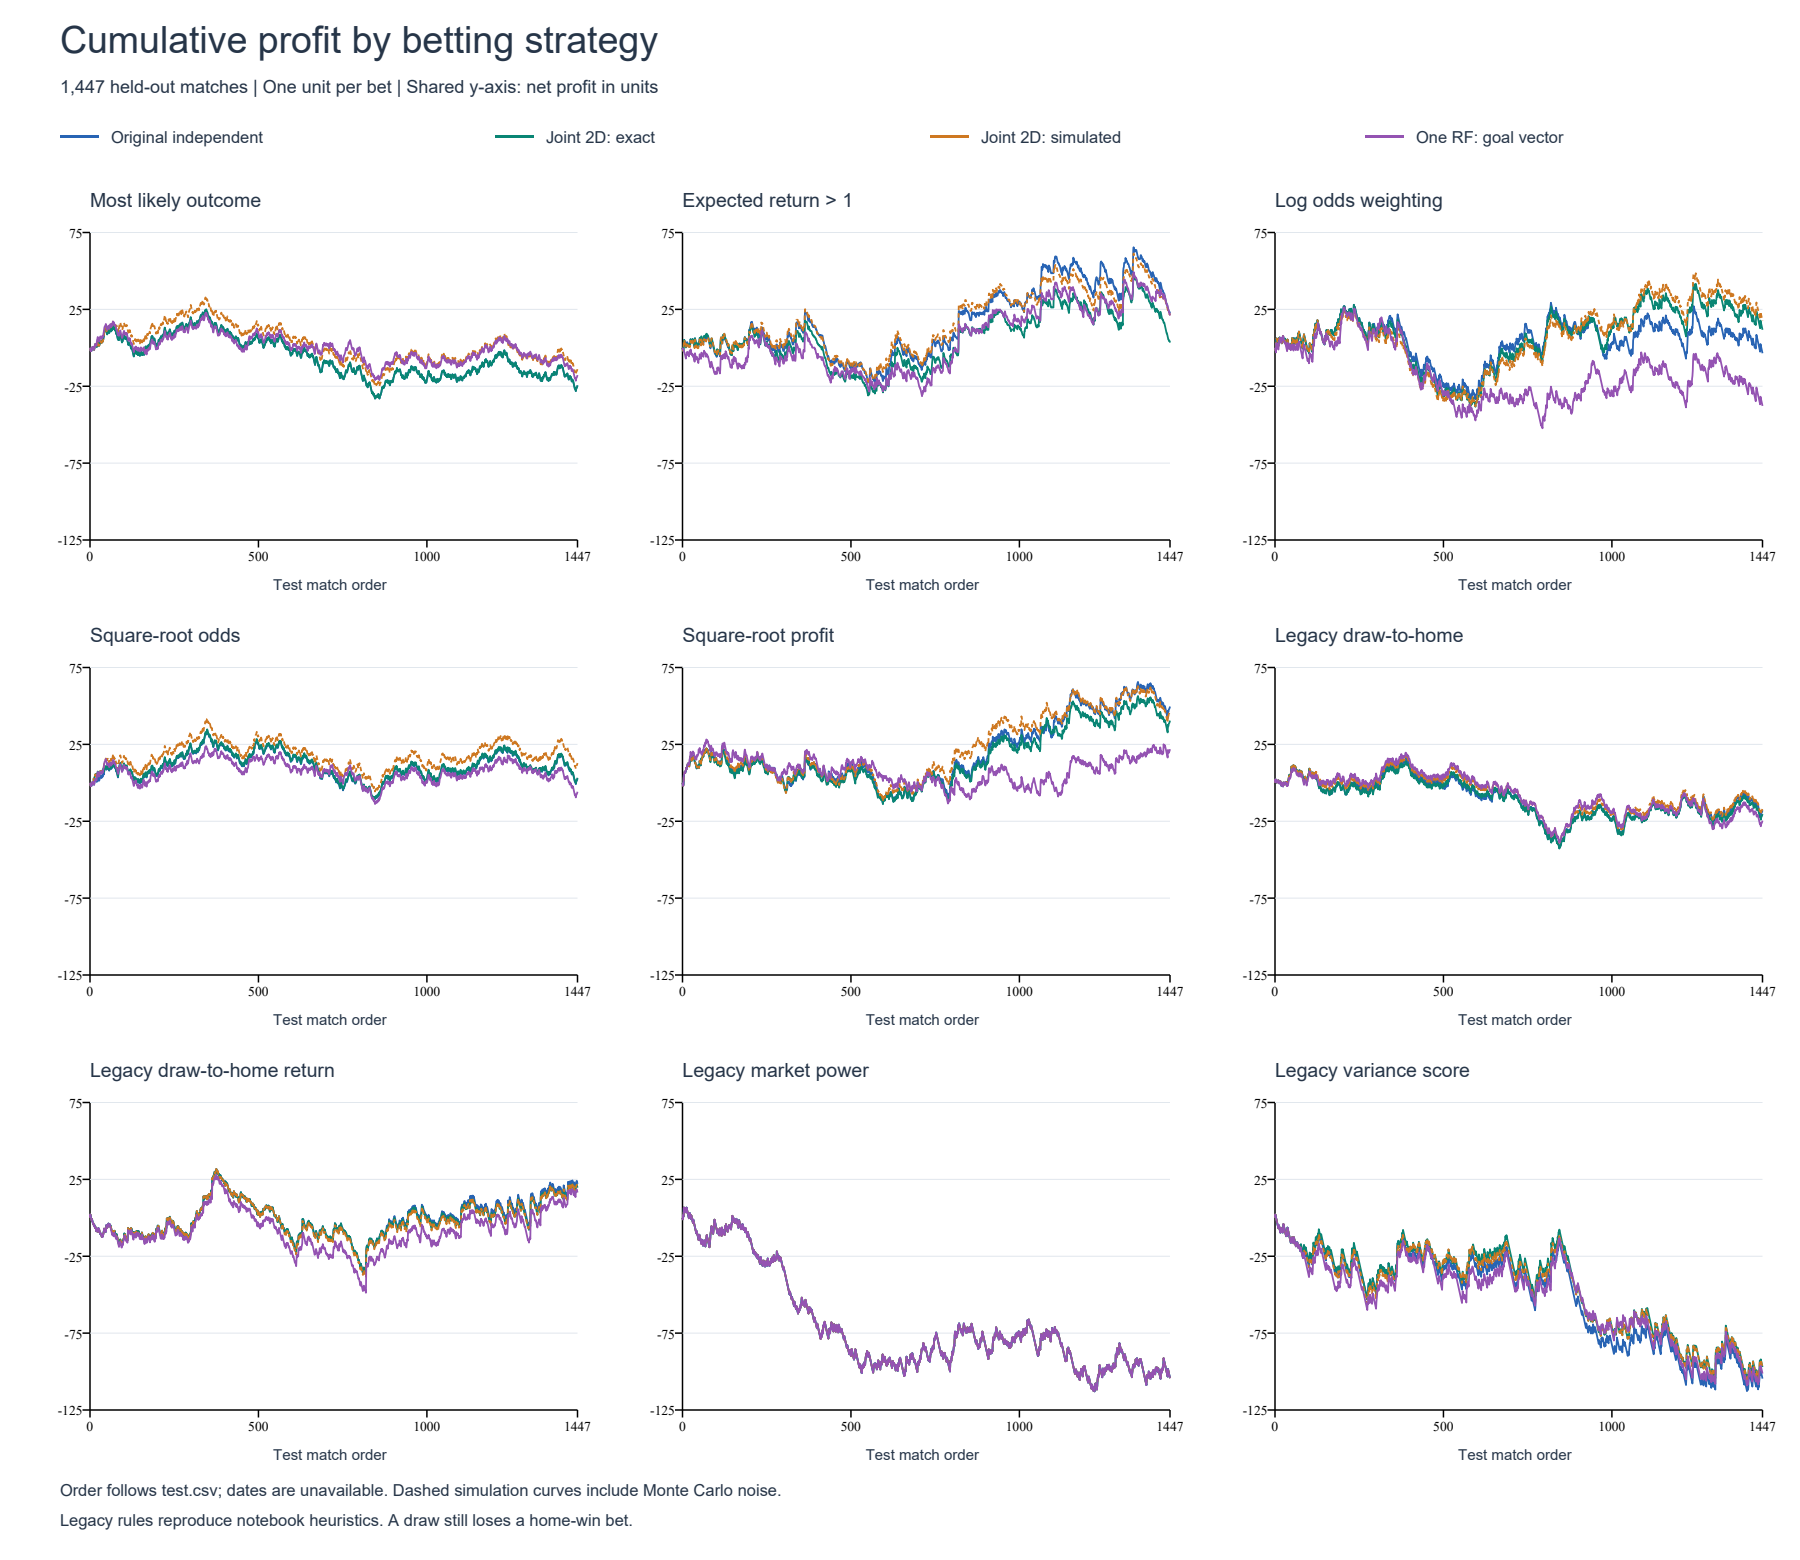

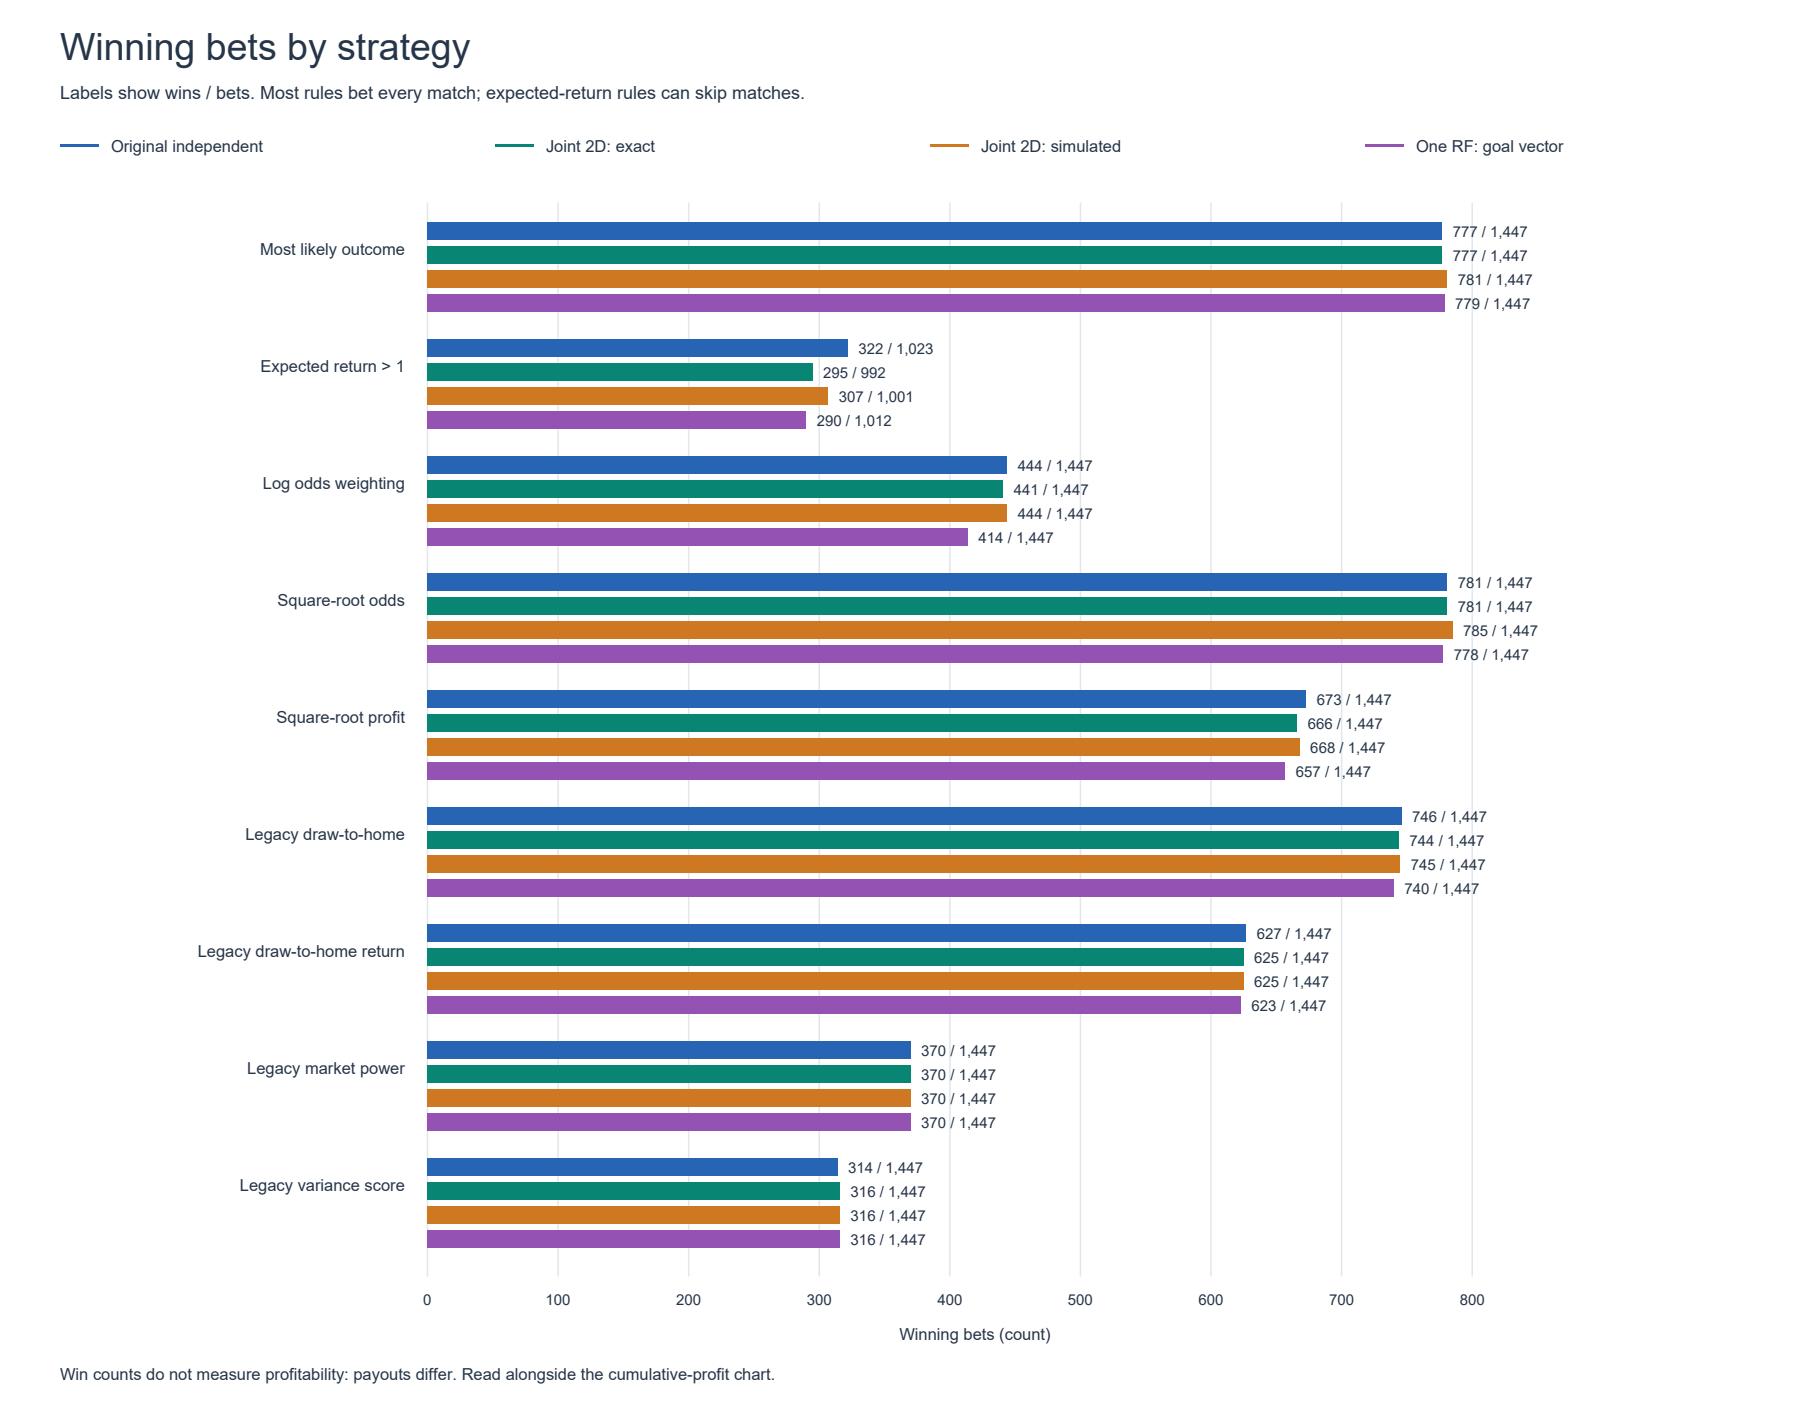

In [ ]:
from IPython.display import Image, display
from plot_bivariate_results import main as make_plots
make_plots()
for name in ["cumulative_profit", "wins_by_strategy"]:
    display(Image(filename=str(experiment.OUT / (name + ".png"))))


## Probability gap versus average winnings
Gap = maximum minus minimum of the three outcome probabilities. Each dot shows the mean gap and mean realized **net profit per one-unit bet**, betting on the most likely outcome. Fixed bins have width 0.10. Counts appear beside each dot; hollow dots have fewer than 30 bets.

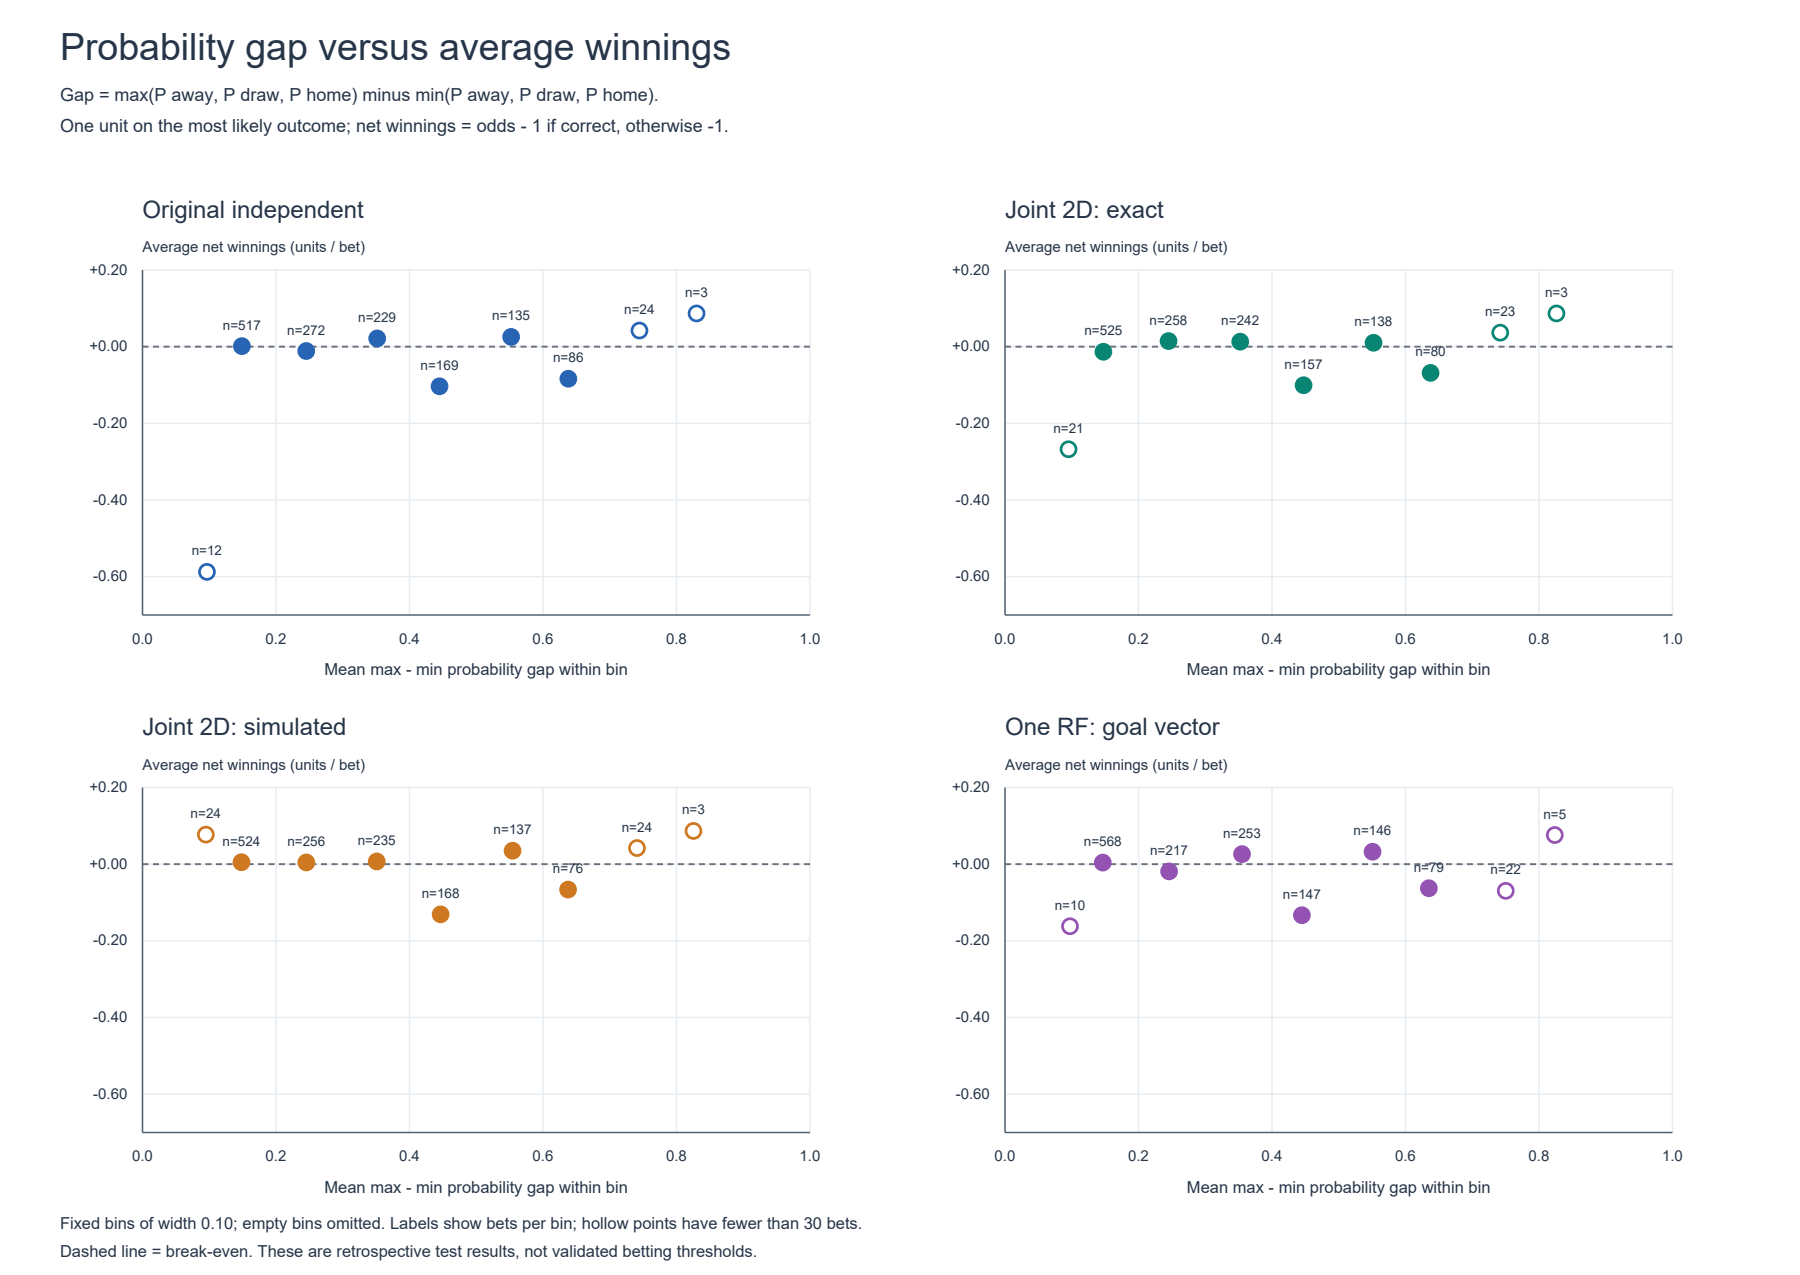

In [ ]:
from plot_probability_gap import main as plot_gap
plot_gap()
display(Image(filename=str(experiment.OUT / "probability_gap_winnings.png")))


In [ ]:
gap_results = pd.read_csv(experiment.OUT / "probability_gap_winnings.csv")
display(gap_results[gap_results.model == "RF_vector"])


## Predictive performance
Lower log loss, Brier score, and joint score NLL are better. Correct predictions means selecting the most likely of away/draw/home.

In [ ]:
metrics = pd.read_csv(experiment.OUT / "model_metrics.csv")
display(metrics)


model,matches,correct,accuracy,log_loss,brier,auc_ovr,predicted_draws,correct_draws,mean_draw_probability,actual_draw_rate,joint_score_nll,home_goal_rmse,away_goal_rmse,home_goal_mse,away_goal_mse,mean_goal_mse,home_goal_mae,away_goal_mae,mean_goal_mae
RF_independent,1447,777,0.53697,0.97879,0.58244,0.66357,0,0,0.23390,0.24326,2.89866,1.24593,1.06679,1.55235,1.13805,1.34520,0.96169,0.83020,0.89595
RF_independent_calibrated,1447,776,0.53628,0.97901,0.58258,0.66362,0,0,0.23392,0.24326,2.89893,1.24607,1.06707,1.55269,1.13863,1.34566,0.96142,0.83089,0.89615
RF_bivariate_exact,1447,777,0.53697,0.97883,0.58248,0.66362,0,0,0.23636,0.24326,2.89877,1.24649,1.06671,1.55373,1.13786,1.34580,0.96179,0.83047,0.89613
RF_bivariate_simulated,1447,781,0.53974,0.97892,0.58257,0.66330,0,0,0.23630,0.24326,2.89877,1.24649,1.06671,1.55373,1.13786,1.34580,0.96179,0.83047,0.89613
RF_vector,1447,779,0.53836,0.97884,0.58266,0.66243,0,0,0.23461,0.24326,2.89903,1.24595,1.06691,1.55240,1.13830,1.34535,0.96185,0.83115,0.89650
Market,1447,778,0.53766,0.98067,0.58397,0.65736,3,0,0.24985,0.24326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Wins per betting strategy
One unit staked per bet. Net profit excludes the original notebook's initial one-unit balance; ROI is net profit divided by bets. Legacy rules are reproduced as heuristics, not presented as valid double-chance bets or Sharpe ratios.

In [ ]:
strategies = pd.read_csv(experiment.OUT / "strategy_results.csv")
display(strategies)


model,strategy,bets,wins,losses,win_rate,net_profit_units,roi
RF_independent,Most likely outcome,1447,777,670,0.53697,-24.46000,-0.01690
RF_independent,Expected return > 1,1023,322,701,0.31476,22.35000,0.02185
RF_independent,Log odds weighting,1447,444,1003,0.30684,-3.54000,-0.00245
RF_independent,Square-root odds weighting,1447,781,666,0.53974,2.79000,0.00193
RF_independent,Square-root profit weighting,1447,673,774,0.46510,49.62000,0.03429
RF_independent,Legacy draw-to-home weighting,1447,746,701,0.51555,-17.85000,-0.01234
RF_independent,Legacy draw-to-home return weighting,1447,627,820,0.43331,22.06000,0.01525
RF_independent,Legacy market power weighting,1447,370,1077,0.25570,-104.29000,-0.07207
RF_independent,Legacy variance score,1447,314,1133,0.21700,-104.59000,-0.07228
RF_independent,Home win or skip (sqrt profit),930,391,539,0.42043,70.45000,0.07575


## New strategy: does the home team lose?
Choose between **home loses** and **home does not lose**, using the existing score probabilities. The second includes both a home win and a draw. Every match stakes one unit in total.

No quoted double-chance odds are available, so home-not-to-lose is constructed by splitting the stake between home win and draw for an equal payout. Its effective decimal odds are `1 / (1 / home_odds + 1 / draw_odds)`. This pays on a draw, unlike the legacy heuristic. It assumes both recorded odds are available with fractional stakes and no fees or rounding.

In [ ]:
binary_summary = pd.read_csv(experiment.OUT / "home_loss_strategy.csv")
display(binary_summary)


model,strategy,bets,wins,losses,win_rate,net_profit_units,roi,home_loss_bets,home_not_loss_bets,loss_side_profit,not_loss_side_profit
RF_independent,Home loses vs not (synthetic double chance),1447,1050,397,0.72564,-52.23682,-0.03610,222,1225,-20.01000,-32.22682
RF_independent_calibrated,Home loses vs not (synthetic double chance),1447,1050,397,0.72564,-52.23682,-0.03610,222,1225,-20.01000,-32.22682
RF_bivariate_exact,Home loses vs not (synthetic double chance),1447,1051,396,0.72633,-50.67084,-0.03502,215,1232,-19.21000,-31.46084
RF_bivariate_simulated,Home loses vs not (synthetic double chance),1447,1052,395,0.72702,-48.86050,-0.03377,214,1233,-18.21000,-30.65050
RF_vector,Home loses vs not (synthetic double chance),1447,1045,402,0.72218,-62.61548,-0.04327,209,1238,-24.44000,-38.17548
Market,Home loses vs not (synthetic double chance),1447,1051,396,0.72633,-54.95770,-0.03798,197,1250,-20.03000,-34.92770


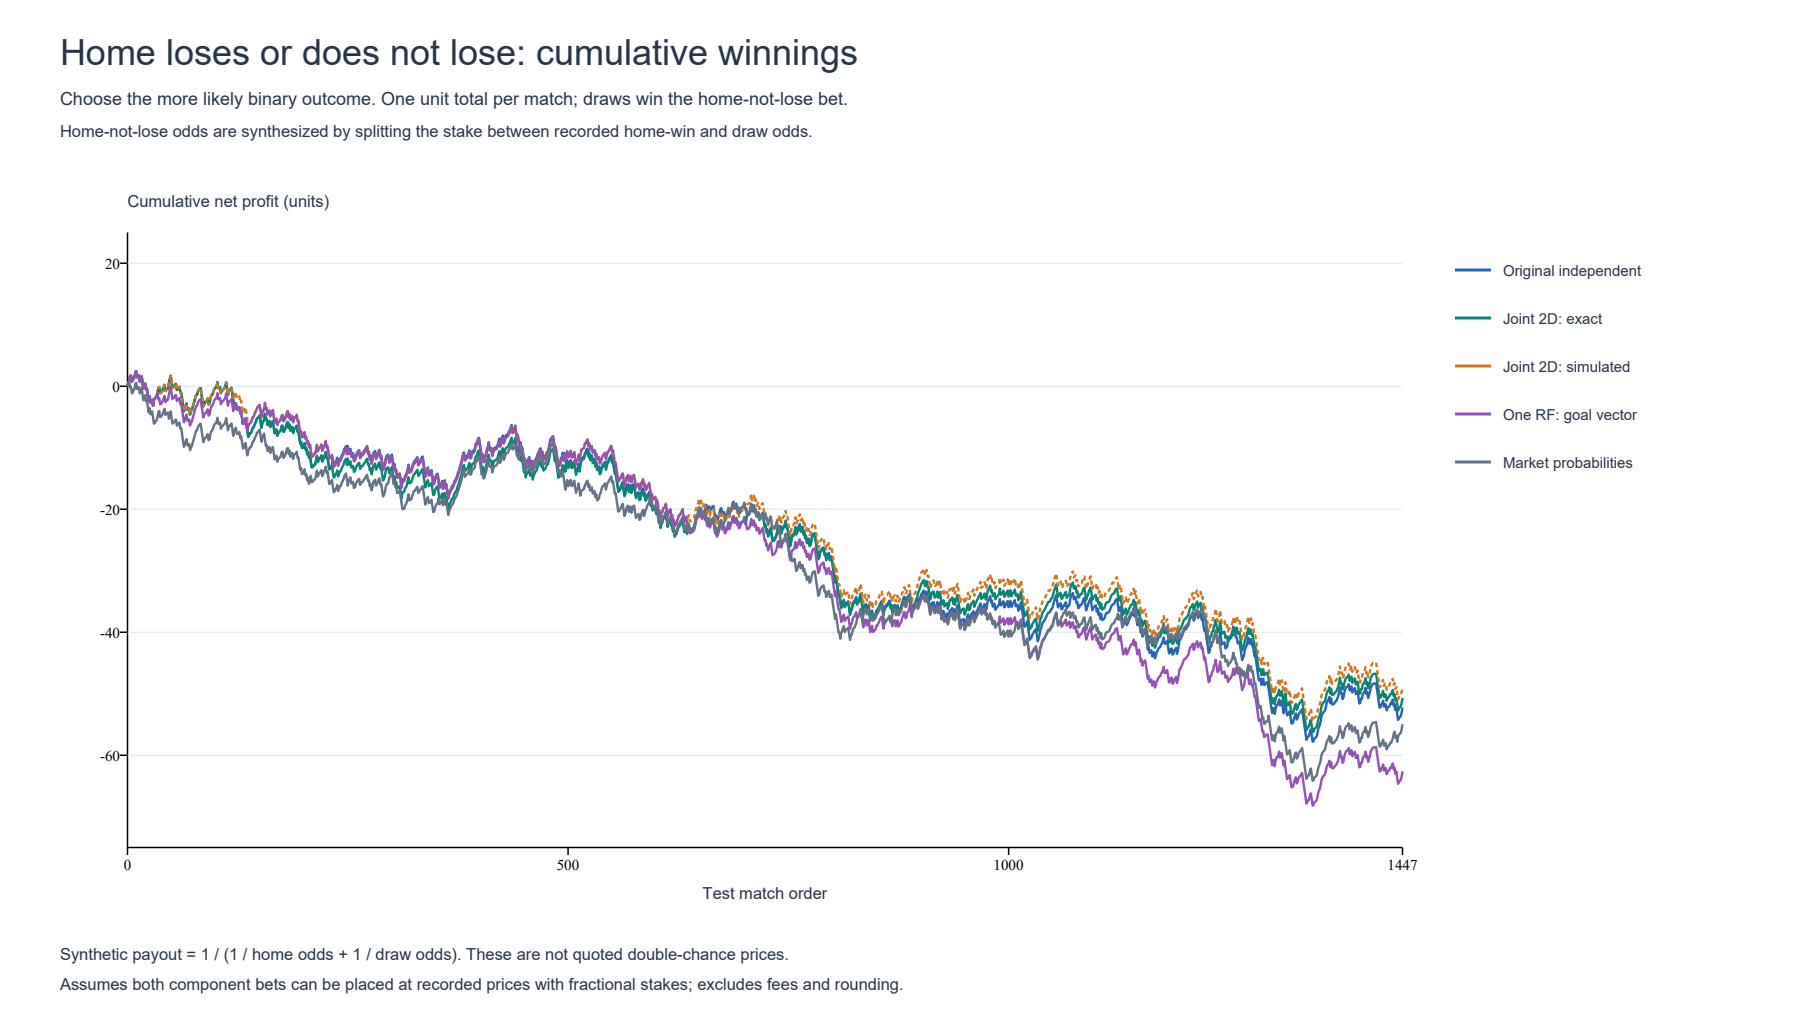

In [ ]:
from evaluate_home_loss import main as evaluate_binary
evaluate_binary()
display(Image(filename=str(experiment.OUT / "home_loss_strategy.png")))


## Home loses or not: square-root-profit strategy
Choose the larger **probability × √(decimal odds − 1)**. Home loses uses the away-win probability and odds; home does not lose uses the home-plus-draw probability and synthetic home-or-draw odds. Stake one unit total per match, with the same split-stake payout assumptions. Synthetic payouts at or below 1 receive zero selection weight: that side cannot produce a positive profit even when correct.

In [ ]:
sqrt_loss_summary = pd.read_csv(experiment.OUT / "home_loss_sqrt_profit_strategy.csv")
display(sqrt_loss_summary)


model,strategy,bets,wins,losses,win_rate,net_profit_units,roi,home_loss_bets,home_not_loss_bets,loss_side_profit,not_loss_side_profit
RF_independent,Home loses vs not (sqrt profit),1447,452,995,0.31237,-187.57298,-0.12963,1202,245,-192.65000,5.07702
RF_independent_calibrated,Home loses vs not (sqrt profit),1447,444,1003,0.30684,-198.46687,-0.13716,1214,233,-198.65000,0.18313
RF_bivariate_exact,Home loses vs not (sqrt profit),1447,453,994,0.31306,-183.56631,-0.12686,1191,256,-190.69000,7.12369
RF_bivariate_simulated,Home loses vs not (sqrt profit),1447,459,988,0.31721,-170.41833,-0.11777,1189,258,-180.69000,10.27167
RF_vector,Home loses vs not (sqrt profit),1447,444,1003,0.30684,-188.92792,-0.13057,1166,281,-187.24000,-1.68792
Market,Home loses vs not (sqrt profit),1447,396,1051,0.27367,-188.67848,-0.13039,1250,197,-194.43000,5.75152


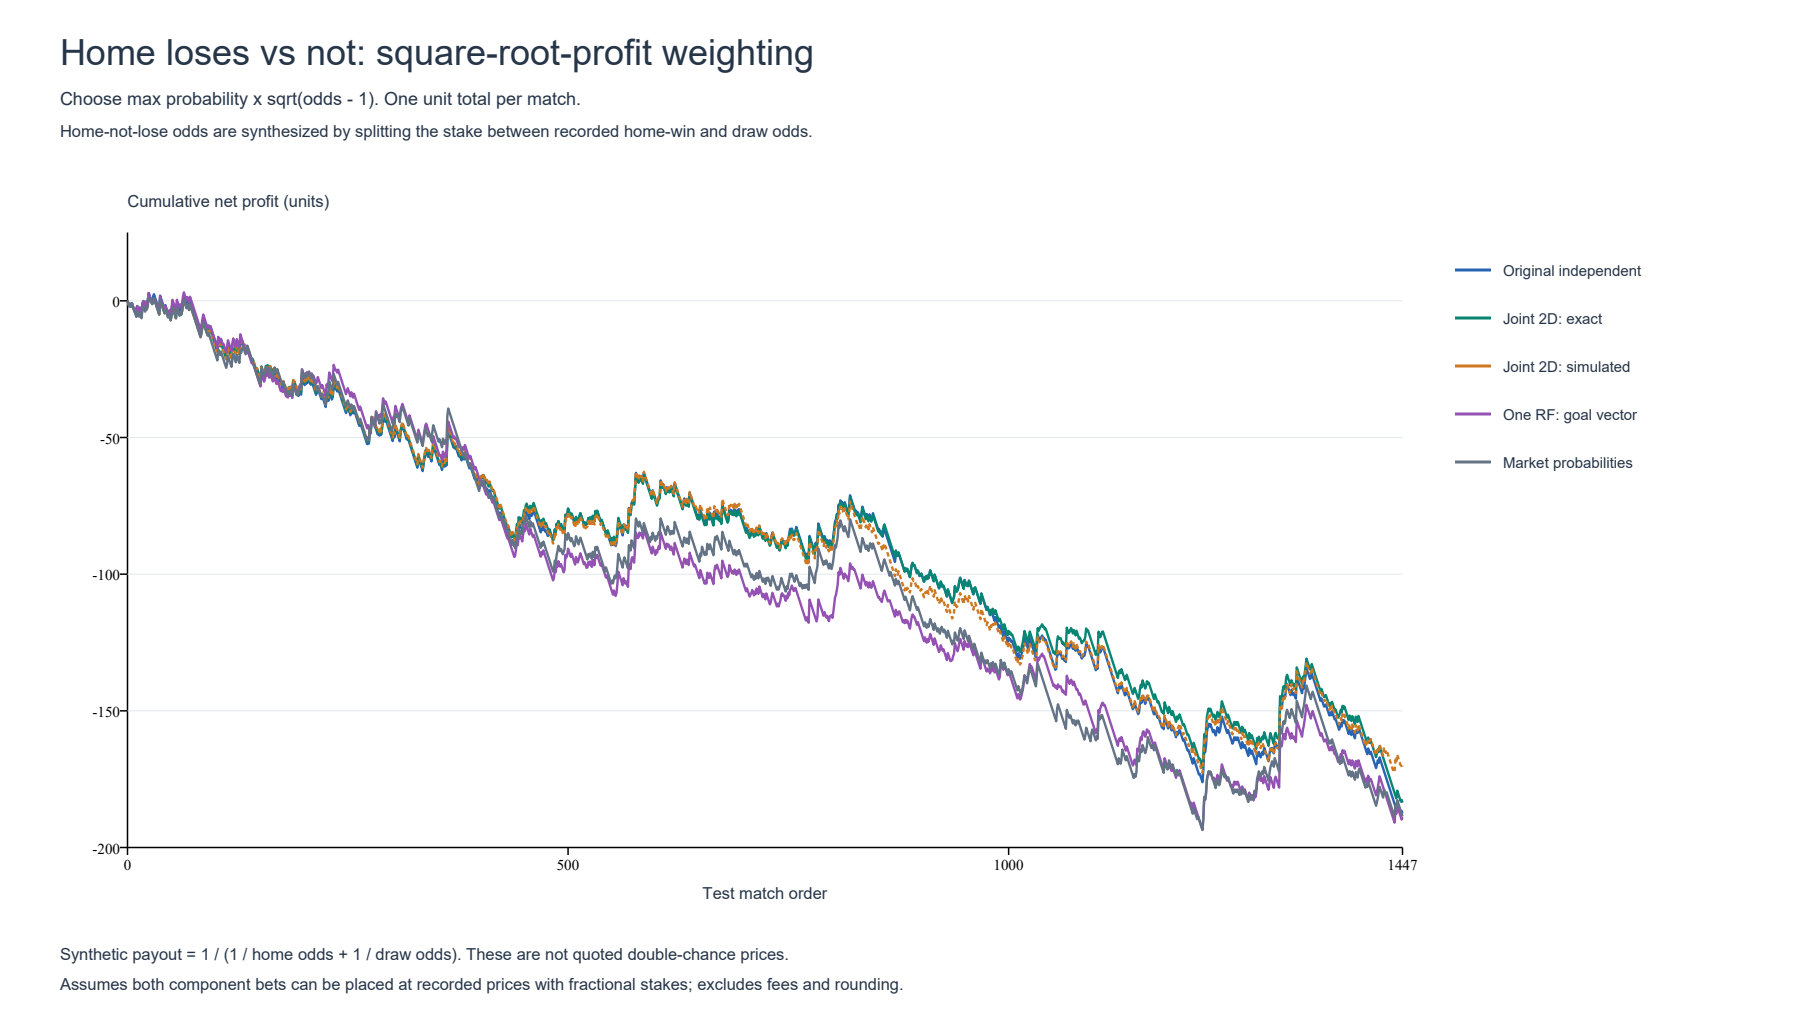

In [ ]:
evaluate_binary("sqrt_profit")
display(Image(filename=str(experiment.OUT / "home_loss_sqrt_profit_strategy.png")))


## New strategy: does the home team win?
Choose the more likely of **home wins** and **home does not win**. Home does not win includes an away win or a draw. Stake one unit in total on each match. The no-win side splits the stake between away and draw, giving effective decimal odds `1 / (1 / away_odds + 1 / draw_odds)`. These are synthetic payouts, not quoted double-chance odds. The same fractional-stake and no-fee assumptions apply.

In [ ]:
binary_win_summary = pd.read_csv(experiment.OUT / "home_win_strategy.csv")
display(binary_win_summary)


model,strategy,bets,wins,losses,win_rate,net_profit_units,roi,home_win_bets,home_not_win_bets,win_side_profit,not_win_side_profit
RF_independent,Home wins vs not (synthetic double chance),1447,943,504,0.65169,-76.73341,-0.05303,530,917,0.82000,-77.55341
RF_independent_calibrated,Home wins vs not (synthetic double chance),1447,944,503,0.65238,-74.80194,-0.05169,527,920,2.02000,-76.82194
RF_bivariate_exact,Home wins vs not (synthetic double chance),1447,945,502,0.65308,-73.00194,-0.05045,526,921,3.02000,-76.02194
RF_bivariate_simulated,Home wins vs not (synthetic double chance),1447,943,504,0.65169,-76.75742,-0.05305,524,923,1.16000,-77.91742
RF_vector,Home wins vs not (synthetic double chance),1447,944,503,0.65238,-75.31676,-0.05205,531,916,1.46000,-76.77676
Market,Home wins vs not (synthetic double chance),1447,939,508,0.64893,-85.50831,-0.05909,502,945,-2.24000,-83.26831


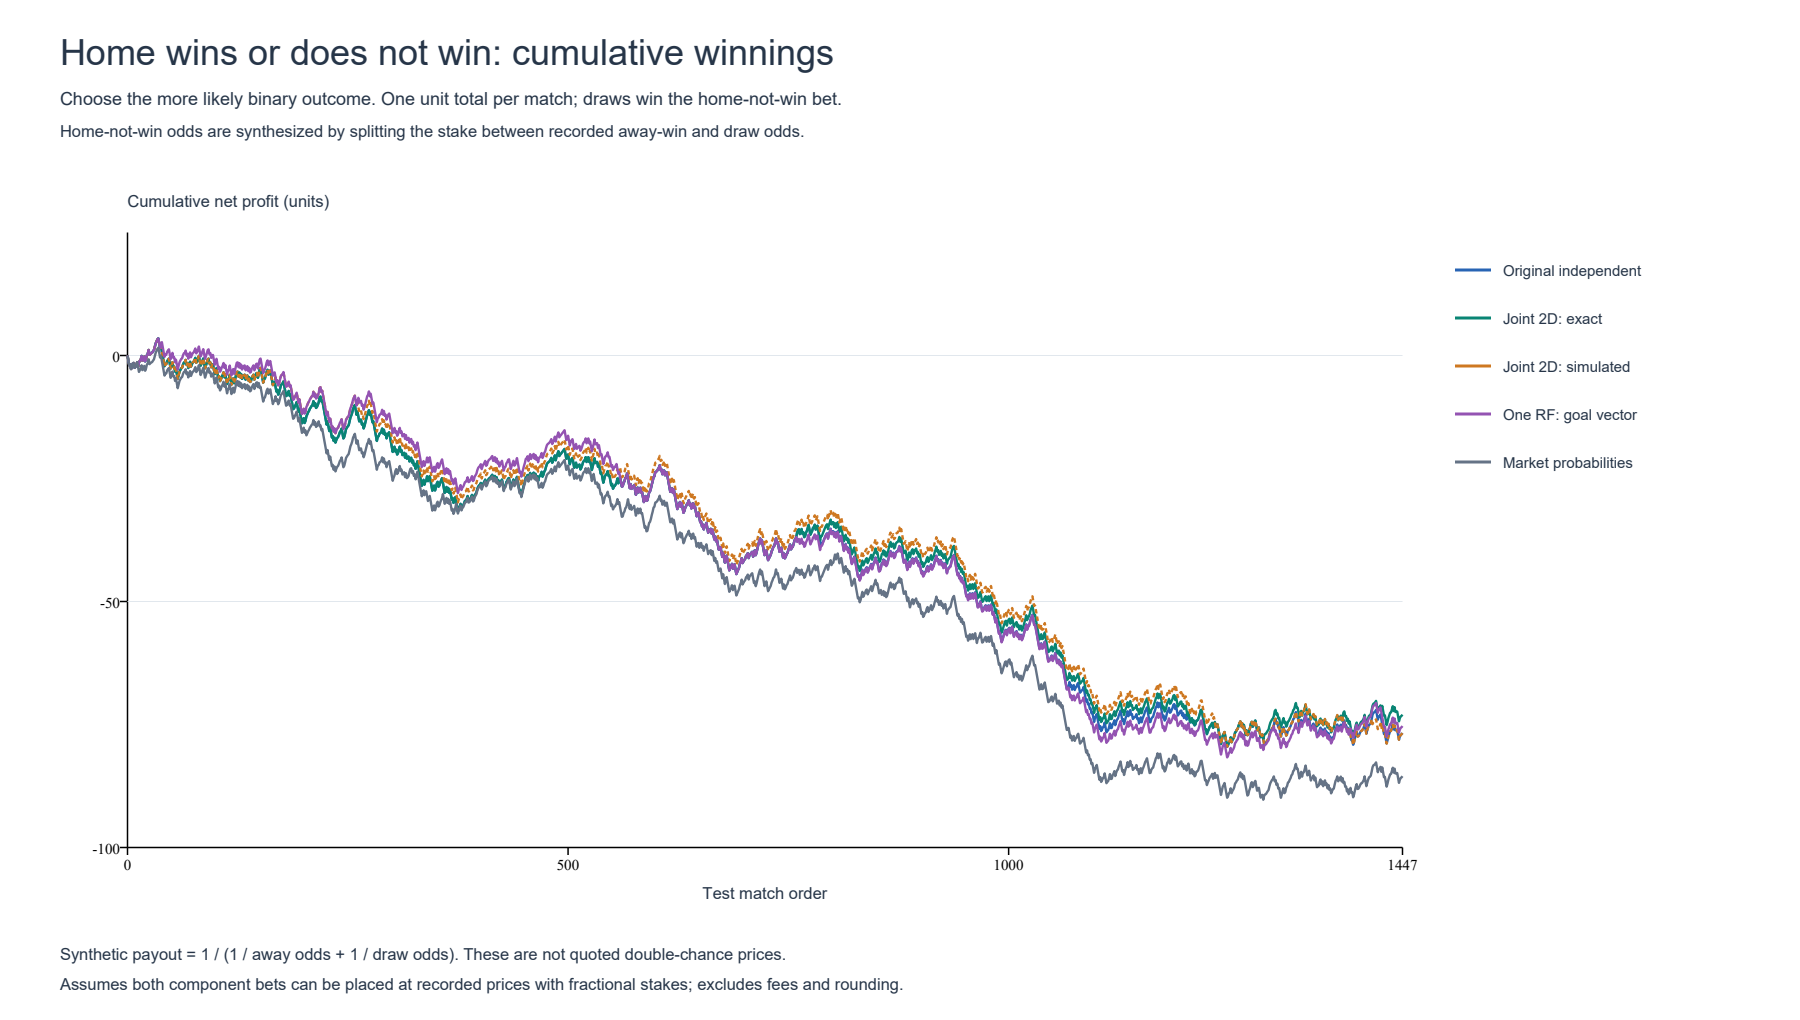

In [ ]:
from evaluate_home_win import main as evaluate_binary_win
evaluate_binary_win()
display(Image(filename=str(experiment.OUT / "home_win_strategy.png")))


## Home wins or not: square-root-profit strategy
Choose the side with the larger **probability × √(decimal odds − 1)**. Use the synthetic away-or-draw odds for home not winning. The stake remains one unit per match; this weighting changes the selected side, not the stake or payout.

In [ ]:
sqrt_win_summary = pd.read_csv(experiment.OUT / "home_win_sqrt_profit_strategy.csv")
display(sqrt_win_summary)


model,strategy,bets,wins,losses,win_rate,net_profit_units,roi,home_win_bets,home_not_win_bets,win_side_profit,not_win_side_profit
RF_independent,Home wins vs not (sqrt profit),1447,627,820,0.43331,33.82828,0.02338,930,517,70.45000,-36.62172
RF_independent_calibrated,Home wins vs not (sqrt profit),1447,636,811,0.43953,47.68973,0.03296,903,544,79.67000,-31.98027
RF_bivariate_exact,Home wins vs not (sqrt profit),1447,631,816,0.43607,47.59295,0.03289,886,561,80.00000,-32.40705
RF_bivariate_simulated,Home wins vs not (sqrt profit),1447,628,819,0.43400,39.44057,0.02726,889,558,75.47000,-36.02943
RF_vector,Home wins vs not (sqrt profit),1447,635,812,0.43884,78.44483,0.05421,942,505,84.38000,-5.93517
Market,Home wins vs not (sqrt profit),1447,508,939,0.35107,-14.91609,-0.01031,945,502,46.50000,-61.41609


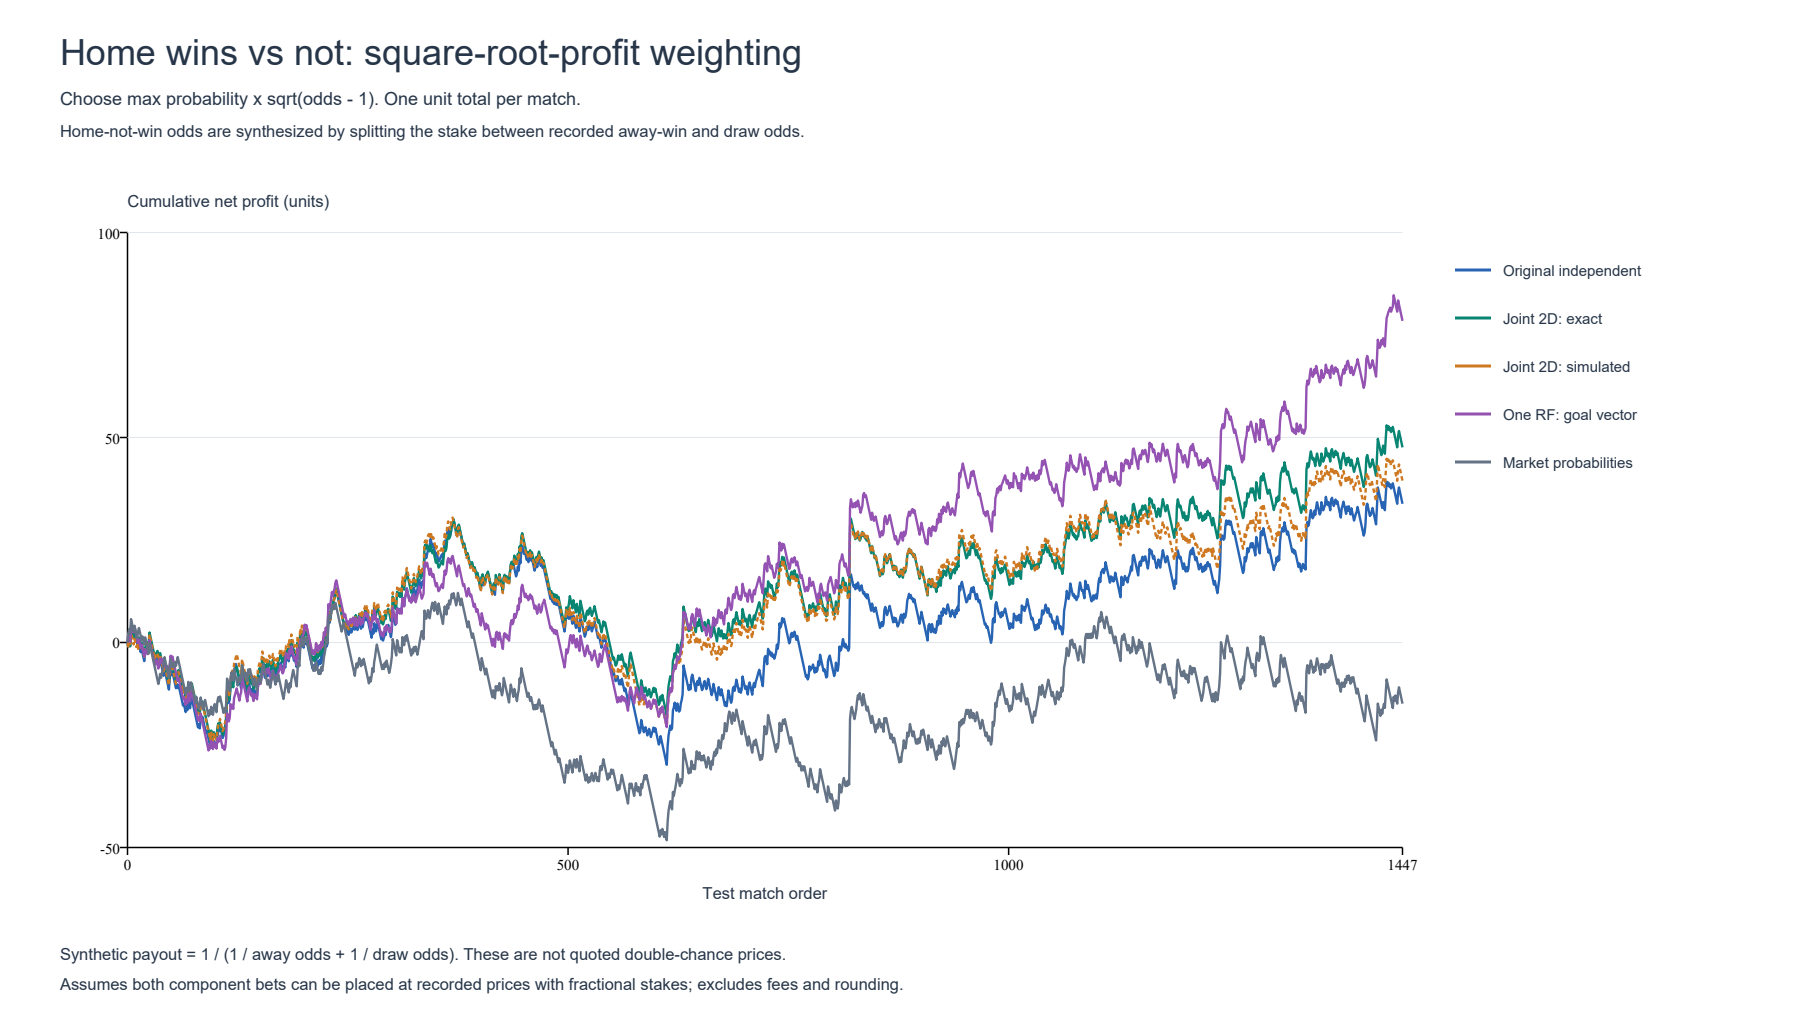

In [ ]:
evaluate_binary_win("sqrt_profit")
display(Image(filename=str(experiment.OUT / "home_win_sqrt_profit_strategy.png")))


## Home win or skip: square-root-profit weighting
Use the same binary comparison above: **p(home) × √(home odds − 1)** versus **(p(away) + p(draw)) × √(synthetic away-or-draw odds − 1)**. Bet one unit on home when its score is at least as high; otherwise **do not bet**. There is no additional expected-utility or positive-return filter. A draw or away win loses a placed bet. Skips have zero stake and profit; ROI divides by placed bets. Square-root weighting affects selection only; reported profit uses actual decimal payouts.

In [ ]:
home_skip_summary = pd.read_csv(experiment.OUT / "home_win_or_skip_strategy.csv")
display(home_skip_summary)


model,strategy,bets,wins,losses,win_rate,net_profit_units,roi,skipped
RF_independent,Home win or skip (sqrt profit),930,391,539,0.42043,70.45000,0.07575,517
RF_independent_calibrated,Home win or skip (sqrt profit),903,382,521,0.42303,79.67000,0.08823,544
RF_bivariate_exact,Home win or skip (sqrt profit),886,371,515,0.41874,80.00000,0.09029,561
RF_bivariate_simulated,Home win or skip (sqrt profit),889,371,518,0.41732,75.47000,0.08489,558
RF_vector,Home win or skip (sqrt profit),942,401,541,0.42569,84.38000,0.08958,505
Market,Home win or skip (sqrt profit),945,339,606,0.35873,46.50000,0.04921,502


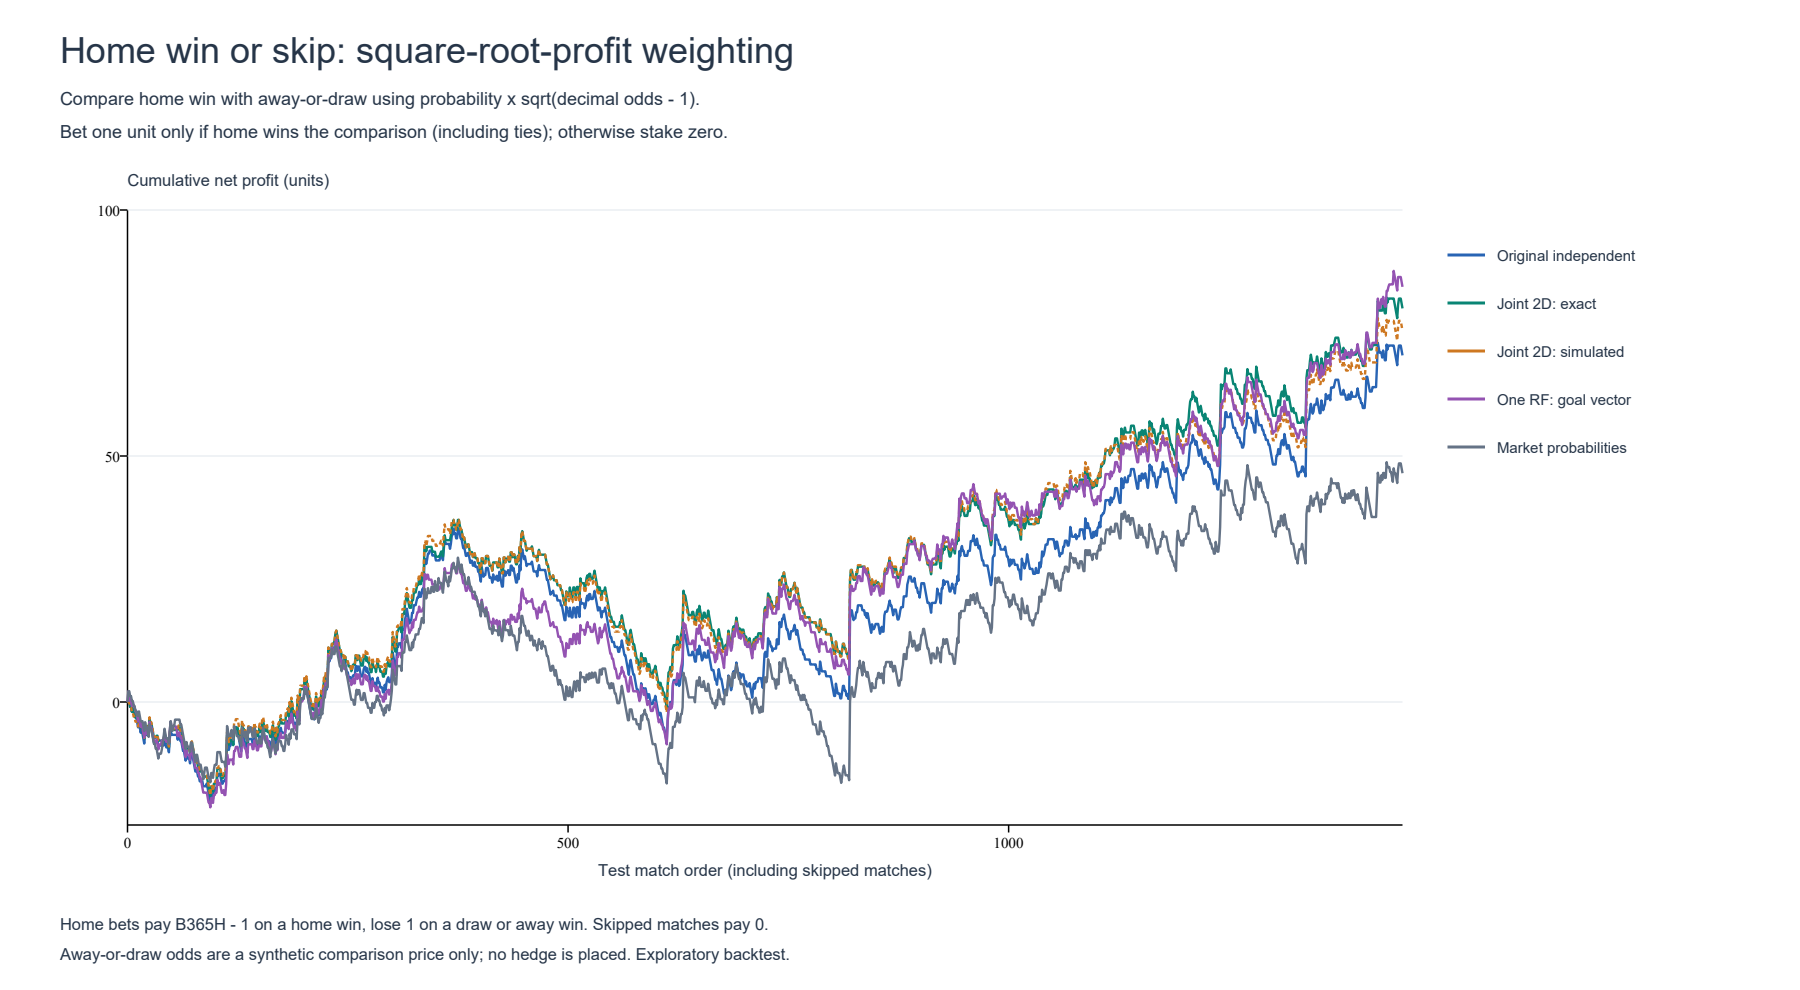

In [ ]:
from plot_home_or_skip import main as plot_home_or_skip
plot_home_or_skip()
display(Image(filename=str(experiment.OUT / "home_win_or_skip_strategy.png")))


## Where do the models fail?
Compare actual versus predicted outcomes and confidence versus observed accuracy below. The CSV diagnostics cover **all models**. Group sizes below 30 are flagged; small differences in small groups should not be treated as established weaknesses. Actual-outcome accuracy is recall for that outcome. Actual outcomes and total goals are retrospective slices, not pre-match predictors. Positive goal bias means overprediction.

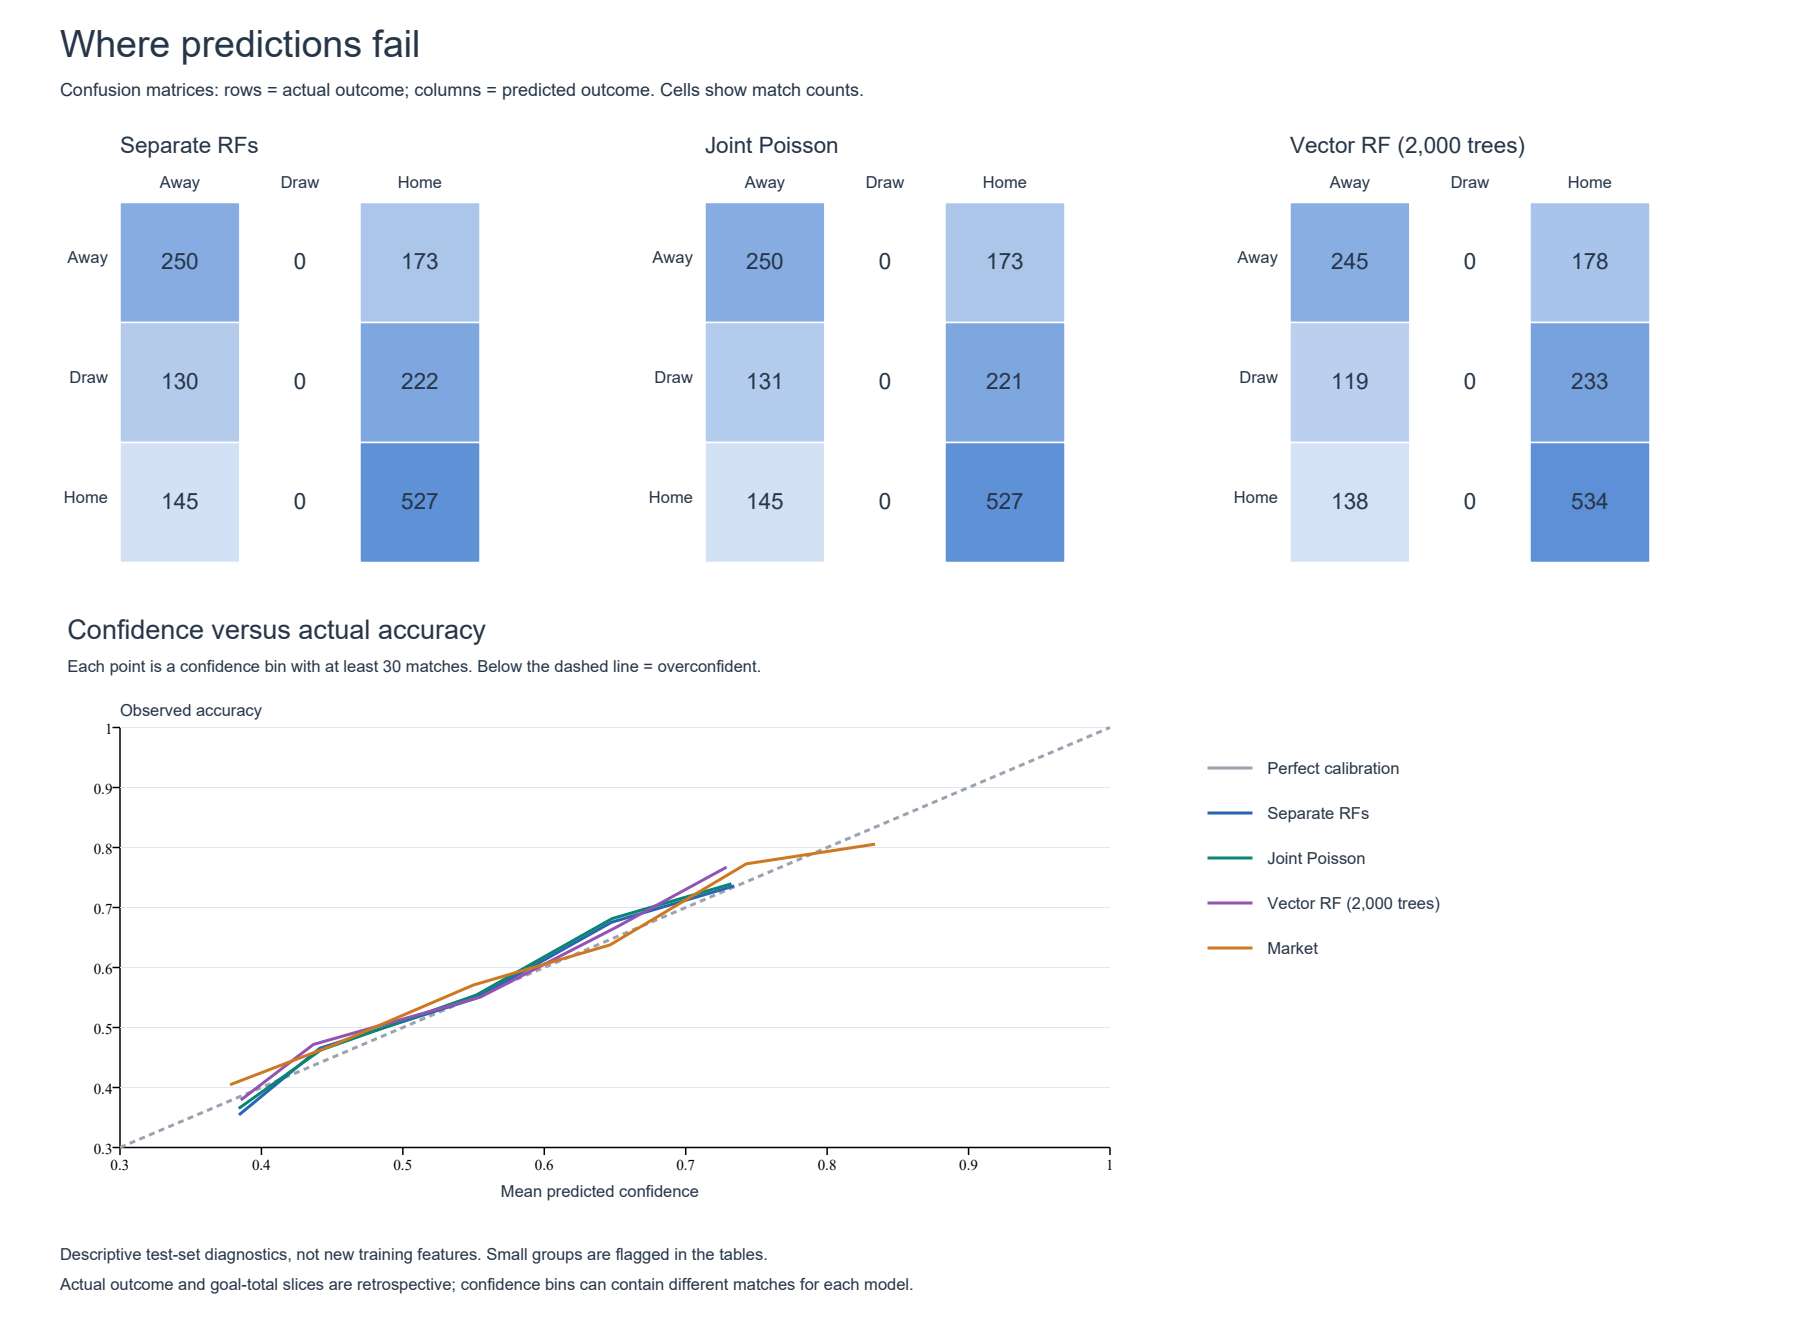

In [ ]:
from analyze_prediction_errors import main as analyze_errors
analyze_errors()
display(Image(filename=str(experiment.OUT / "failure_diagnostics.png")))


In [ ]:
error_slices = pd.read_csv(experiment.OUT / "error_slices.csv")
ERROR_MODEL = "RF_vector"  # Change to RF_independent, RF_bivariate_exact, Market, etc.
error_columns = ['model', 'area', 'group', 'matches', 'small_sample', 'accuracy', 'mean_log_loss', 'mean_confidence', 'goal_mae', 'home_goal_bias', 'away_goal_bias']
display(error_slices.loc[error_slices.model == ERROR_MODEL, error_columns])


model,area,group,matches,small_sample,accuracy,mean_log_loss,mean_confidence,goal_mae,home_goal_bias,away_goal_bias
RF_vector,Overall,All matches,1447,False,0.53836,0.97884,0.52227,0.89650,-0.04603,0.05489
RF_vector,Actual outcome (retrospective),Away,423,False,0.57920,0.97889,0.49932,0.96291,0.75022,-0.80415
RF_vector,Actual outcome (retrospective),Draw,352,False,0.00000,1.43405,0.50298,0.73336,0.41891,0.17583
RF_vector,Actual outcome (retrospective),Home,672,False,0.79464,0.74037,0.54682,0.94015,-0.79078,0.53227
RF_vector,Actual total goals (retrospective),0–1,346,False,0.47110,1.04910,0.50651,0.99008,1.01925,0.94598
RF_vector,Actual total goals (retrospective),2–3,686,False,0.53936,0.97799,0.51874,0.62612,0.14695,0.13133
RF_vector,Actual total goals (retrospective),4–5,312,False,0.55449,0.96494,0.53305,1.03216,-0.93100,-0.59881
RF_vector,Actual total goals (retrospective),6+,103,False,0.70874,0.79064,0.56609,1.97198,-2.22914,-1.46747
RF_vector,Player rating gap (absolute),0–2,441,False,0.46485,1.05237,0.45824,0.85790,-0.05056,0.13035
RF_vector,Player rating gap (absolute),2–5,530,False,0.52264,0.99712,0.49704,0.88673,-0.05278,0.00010


### Compare outcome recall across models

In [ ]:
outcome_errors = error_slices[error_slices.area == "Actual outcome (retrospective)"]
display(outcome_errors.pivot(index="model", columns="group", values="accuracy").reset_index())


group,model,Away,Draw,Home
,Market,0.58865,0.00000,0.78720
,RF_bivariate_exact,0.59102,0.00000,0.78423
,RF_bivariate_simulated,0.59574,0.00000,0.78720
,RF_independent,0.59102,0.00000,0.78423
,RF_independent_calibrated,0.59102,0.00000,0.78274
,RF_vector,0.57920,0.00000,0.79464


### Most difficult teams
Teams are ranked by average outcome log loss, with at least 30 matches. Each team group includes both home and away games; these groups overlap.

In [ ]:
team_errors = pd.read_csv(experiment.OUT / "team_errors.csv")
display(team_errors[(team_errors.model == ERROR_MODEL) & (team_errors.matches >= 30)].sort_values("mean_log_loss", ascending=False).head(10)[error_columns])


model,area,group,matches,small_sample,accuracy,mean_log_loss,mean_confidence,goal_mae,home_goal_bias,away_goal_bias
RF_vector,Team (home or away),Brentford,38,False,0.42105,1.15689,0.49898,1.01034,-0.15931,0.13525
RF_vector,Team (home or away),Mainz 05,34,False,0.44118,1.12550,0.48215,1.01586,-0.27851,-0.21319
RF_vector,Team (home or away),Köln,34,False,0.38235,1.10385,0.48754,1.11889,-0.32676,0.01882
RF_vector,Team (home or away),Gladbach,34,False,0.38235,1.10150,0.49150,1.07233,-0.50195,0.14053
RF_vector,Team (home or away),Salernitana,38,False,0.44737,1.09765,0.52744,0.94720,-0.27660,0.10105
RF_vector,Team (home or away),Leverkusen,34,False,0.47059,1.08789,0.52133,1.02509,-0.19831,-0.06385
RF_vector,Team (home or away),Chelsea,38,False,0.44737,1.08295,0.54700,0.87937,0.30216,0.30897
RF_vector,Team (home or away),Monza,38,False,0.42105,1.08022,0.49417,0.82765,-0.00179,0.02192
RF_vector,Team (home or away),Rayo Vallecano,38,False,0.36842,1.07392,0.47826,0.79788,-0.10809,0.14606
RF_vector,Team (home or away),Brighton & Hove Albion,38,False,0.47368,1.06852,0.51819,1.12278,-0.26113,-0.24864


### Inspect individual failures
The wrong predictions with the largest log loss: matches where the actual result received particularly low probability.

In [ ]:
worst_predictions = pd.read_csv(experiment.OUT / "worst_predictions.csv")
display(worst_predictions[worst_predictions.model == ERROR_MODEL])


model,source_test_row,home_team_name,away_team_name,home_score,away_score,predicted_outcome,confidence,actual_outcome_probability,log_loss,p_Away,p_Draw,p_Home
RF_vector,1307,Manchester City,Brentford,1,2,Home,0.79830,0.06995,2.65992,0.06995,0.13175,0.79830
RF_vector,819,Augsburg,Bayern Munich,1,0,Away,0.75272,0.09330,2.37199,0.75272,0.15399,0.09330
RF_vector,1326,Liverpool,Leeds United,1,2,Home,0.74053,0.09809,2.32191,0.09809,0.16138,0.74053
RF_vector,568,Inter,Empoli,0,1,Home,0.73113,0.10163,2.28640,0.10163,0.16724,0.73113
RF_vector,1221,Chelsea,Southampton,0,1,Home,0.72468,0.10535,2.25044,0.10535,0.16997,0.72468
RF_vector,1337,Nottingham Forest,Liverpool,1,0,Away,0.72170,0.10942,2.21260,0.72170,0.16888,0.10942
RF_vector,773,Leverkusen,Augsburg,1,2,Home,0.70589,0.11545,2.15893,0.11545,0.17866,0.70589
RF_vector,783,Dortmund,Werder Bremen,2,3,Home,0.70059,0.11863,2.13177,0.11863,0.18078,0.70059
RF_vector,1285,Manchester City,Everton,1,1,Home,0.80981,0.12149,2.10794,0.06870,0.12149,0.80981
RF_vector,1145,Tottenham Hotspur,AFC Bournemouth,2,3,Home,0.69132,0.12370,2.08986,0.12370,0.18497,0.69132


### Calibration for each outcome
Compare predicted probability with actual frequency separately for away wins, draws, and home wins. The plot above instead checks confidence in the most likely result. Confidence bins can contain different matches across models.

In [ ]:
calibration = pd.read_csv(experiment.OUT / "outcome_calibration.csv")
display(calibration[(calibration.model == ERROR_MODEL) & (calibration.matches >= 30)])


## Per-match probabilities and fitted rates

In [ ]:
predictions = pd.read_csv(experiment.OUT / "match_predictions.csv")
display(predictions.head())


## Method and limitations

This experiment adapts the random-forest branch of prediction.ipynb. It uses the same
features, hyperparameter grid and train.csv/test.csv split, with fixed random seeds and correct
row alignment. The absent league column is omitted. Betting odds remain input features, as in
the source notebook. Seven incomplete training rows are dropped; no test labels train the models.
The baseline is a reproducible refit, not the old pickle. Only the RF branch is compared here.

RF_vector is ONE native multi-output RandomForestRegressor fitted to the two-column
target [home_score, away_score]. All 2,000 trees share splits across both targets; it is
not a MultiOutputRegressor wrapper. Depth=5, max_features=0.3, and max_samples=0.5
are held at the previous training-CV-selected values to isolate the loss change.
The vector model uses criterion='squared_error' and training out-of-bag MSE scoring.
No new hyperparameter search is performed; the previous settings are held fixed.
Its predictions average leaf means across trees to estimate conditional means.
For the RF_vector outcome/betting comparison, these point predictions feed the original independent
Poisson/Skellam conversion. The separate-forest baselines retain 200 trees each, so the
comparison also differs in tree count. Shared-tree prediction does NOT remove the
conditional independence assumption in the outcome conversion. Squared-error training estimates
goal means but does not establish a Poisson distribution. Rates are floored at 1e-8 only for
probability conversion; MSE, MAE, and RMSE use raw predictions and are all reported.

The joint model retains the RF predictors as offsets: u=RF_home*exp(b_home),
v=RF_away*exp(b_away), c=exp(g0+g_home*log(RF_home)+g_away*log(RF_away)).
Five global coefficients are fitted by joint score likelihood on three-fold out-of-fold TRAIN
predictions. Each match receives three rates. H=Poisson(u)+W and A=Poisson(v)+W,
where W=Poisson(c) is shared. Dependence is constrained to be nonnegative.
This is a joint calibration layer, not end-to-end joint training of the forests. A separately
calibrated independent control estimates only the two mean-scale coefficients using the same OOF data.
Hyperparameter selection uses all training folds; this is not nested or chronological validation.
The CSVs contain no dates, so a clean temporal split or upstream feature leakage cannot be verified.

Simulation uses 50,000 score pairs per match and a fixed seed. Exact probabilities are also reported
because the shared count cancels from H-A, which is Skellam(u,v). Use exact results to distinguish
model changes from Monte Carlo variation. Joint score NLL assesses the full 2D distribution.

Each bet stakes one unit. A win earns decimal_odds-1; a loss costs one unit. Profit excludes the
original notebook's arbitrary initial one-unit balance. ROI=net_profit/number_of_bets.
The nine original decision rules are reproduced, including legacy heuristics. Moving draw
probability into the home column is only a selection heuristic: a real draw still loses a home-win
bet; these are not double-chance bets. The original 'Sharpe' expression is labeled a legacy score,
not a Sharpe ratio. Market power weighting uses only market probabilities and must match across models.
No strategy or threshold is selected using these test results. Test profit is a retrospective result.
